# Computer Exercise 15.6 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.6 Policy Gradient Methods — *REINFORCE and Actor-Critic*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-21

---

## 1. 문제 (원문)

> **1.** Consider the *short-corridor with switched actions* problem (Sutton & Barto, Example 13.1).
> There are four states $s\in\{0,1,2,3\}$; state $3$ is terminal. From each non-terminal state the
> agent chooses $\text{left}$ or $\text{right}$. In states $0$ and $2$ the actions have their usual
> effect, but in state $1$ the actions are *reversed*. Attempting to move left from state $0$ leaves
> the agent in state $0$. All non-terminal transitions yield reward $-1$. Because the state features
> cannot distinguish state $1$ from states $0$ and $2$, any deterministic policy performs poorly:
> the greedy "always right" policy gets stuck bouncing between $0$ and $1$, while "always left"
> never leaves state $0$. Show empirically that a **scalar-parameter softmax policy trained by
> vanilla REINFORCE** (with step size $\alpha = 2^{-13}$) converges to a *stochastic* optimum
> $p^{\star} \approx 0.59$ with expected return $J^{\star}\approx -11.6$, and produce a learning
> curve averaged over 100 independent runs.

### 한국어 풀이용 정리
동일한 상태 특성(state feature)을 갖는 세 개의 비종단 상태 중 하나(**state 1**) 에서
행동이 뒤바뀌기 때문에, **결정론적 정책**은 항상 나쁘다. 항상 오른쪽이면 0↔1 사이에 무한 진동,
항상 왼쪽이면 0에서 꼼짝없이 머문다. 즉 최적 정책은 반드시 **확률적**이어야 하며, 이 예제는
정책을 직접 파라미터화하는 **정책 경사(policy gradient)**가 왜 필수적인지 보여주는 표준 예제다.
스칼라 파라미터 $\theta$ 를 갖는 softmax 정책 $\pi(\text{right}|s) = \sigma(\theta)$ 를
$\alpha = 2^{-13}$ 인 vanilla REINFORCE 로 학습해 $p^\star\approx 0.59$ 로 수렴시키고 100회
반복 실행의 평균 학습 곡선을 그린다.

## 2. 수학적 배경

### 2.1 정책 파라미터화
모든 상태에서 동일한 스칼라 파라미터 $\theta\in\mathbb R$ 를 공유하는 softmax 정책:

$$
\pi_\theta(\text{right}\,|\,s) \;=\; \sigma(\theta) \;=\; \frac{1}{1+e^{-\theta}},\qquad
\pi_\theta(\text{left}\,|\,s) \;=\; 1-\sigma(\theta).
$$

로그-그래디언트는 초등적으로 계산된다:

$$
\nabla_\theta \log \pi_\theta(a\,|\,s) \;=\;
\begin{cases}
1 - \sigma(\theta),& a=\text{right},\\[2pt]
-\,\sigma(\theta), & a=\text{left},
\end{cases}
\;=\; a - \sigma(\theta).
$$

### 2.2 정책 경사 정리 (Policy Gradient Theorem)
목표는 시작 상태 $s_0$ 로부터의 기대 리턴 $J(\theta)=\mathbb E_{\tau\sim\pi_\theta}[\sum_t r_t]$
의 최대화. 정책 경사 정리에 의해

$$
\nabla_\theta J(\theta) \;=\; \mathbb E_{\tau\sim\pi_\theta}\Bigl[\,\sum_{t=0}^{T-1} G_t\;\nabla_\theta \log\pi_\theta(a_t|s_t)\,\Bigr],\qquad G_t = \sum_{k=t}^{T-1} \gamma^{k-t} r_k.
$$

### 2.3 REINFORCE (Monte-Carlo policy gradient)
한 에피소드 롤아웃 뒤 각 시점에 대해 다음 확률적 경사 상승:

$$
\boxed{\;\theta \;\gets\; \theta \;+\; \alpha\,\gamma^{\,t}\,G_t\,\bigl(a_t - \sigma(\theta)\bigr)\;}
$$

여기서는 $\gamma=1$ (undiscounted). $G_t$ 는 남은 스텝의 보상 합 $=-\,(T-t)$.

### 2.4 왜 이 문제가 정책경사에 결정적인가
가치함수 기반 방법 (Q-learning, SARSA) 은 표현공간 안에서 **결정론적** greedy 정책을 만든다.
Short-corridor 예제에서 상태특성이 세 개 비종단 상태를 구분하지 못하므로 greedy 정책은
"항상 왼쪽" 또는 "항상 오른쪽" 둘 중 하나이고 두 경우 모두 리턴이 매우 나쁘다. 반면
정책경사는 확률 $p^\star$ 를 직접 조정하므로 확률적 최적을 찾는다.

## 3. 풀이 흐름

1. **환경 구현** — `next_state(s, a)` 로 짧은 복도 (상태 1 은 뒤바뀜) 를 코딩. 각 스텝 보상 $-1$.
2. **정책 & 로그-경사** — $\pi(\text{right}|s)=\sigma(\theta)$, $\nabla\log\pi = a-\sigma(\theta)$.
3. **REINFORCE 루틴** — 에피소드 롤아웃 후 $G_t$ 계산 → 파라미터 갱신 (알파 $=2^{-13}$).
4. **100 회 반복** — 서로 다른 시드로 1000 에피소드씩 학습, 매 에피소드 리턴을 기록.
5. **참값 확인** — 이론적 최적 $p^\star$ 를 격자탐색으로 확인해 $\approx 0.59$, $J^\star\approx -11.6$ 임을 검증.
6. **학습 곡선 시각화** — 100회 평균 리턴 vs 에피소드 (음의 값이 0에 가까워질수록 좋음).

In [1]:
# --- 공통 환경: Short Corridor with Switched Actions (Sutton & Barto Ex. 13.1) -----------
# 상태: 0 (start), 1 (switched), 2, 3 (terminal)
# 행동: 0 = left, 1 = right
# 정상 상태 (0, 2): right -> +1, left -> -1
# 상태 1: 행동이 뒤바뀐다.  right -> -1, left -> +1
# 벽 밖으로 나가면 그 자리에 머문다.  각 스텝의 보상은 -1, 종단은 보상 0.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RIGHT, LEFT = 1, 0
N_STATES = 4          # 0,1,2,3  (3은 종단)
TERMINAL = 3

def next_state(s: int, a: int) -> int:
    """상태 전이. 결정론적."""
    if s == 1:                       # switched
        a_eff = 1 - a
    else:
        a_eff = a
    if a_eff == RIGHT:
        ns = s + 1
    else:
        ns = s - 1
    if ns < 0:
        ns = 0                       # 왼쪽 벽
    return ns


def sigmoid(x: float) -> float:
    # 오버플로 안전 sigmoid
    if x >= 0:
        z = np.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = np.exp(x)
        return z / (1.0 + z)


def run_episode(theta: float, rng: np.random.Generator, max_steps: int = 1000):
    """스칼라 파라미터 theta 를 갖는 softmax 정책으로 한 에피소드 롤아웃."""
    p_right = sigmoid(theta)
    s = 0
    S, A, R = [], [], []
    for _ in range(max_steps):
        a = RIGHT if rng.random() < p_right else LEFT
        ns = next_state(s, a)
        r = -1.0
        S.append(s); A.append(a); R.append(r)
        if ns == TERMINAL:
            break
        s = ns
    return np.array(S), np.array(A), np.array(R)


def expected_return(theta: float) -> float:
    """이 정책의 기대 리턴을 몬테카를로로 추정."""
    rng = np.random.default_rng(0)
    G = []
    for _ in range(200):
        _, _, R = run_episode(theta, rng, max_steps=5000)
        G.append(R.sum())
    return float(np.mean(G))


격자탐색: p* ~= 0.550,  J(p*) ~= -10.79
        (참조: Sutton & Barto, Fig. 13.1 -> p* ~= 0.59, J* ~= -11.6)


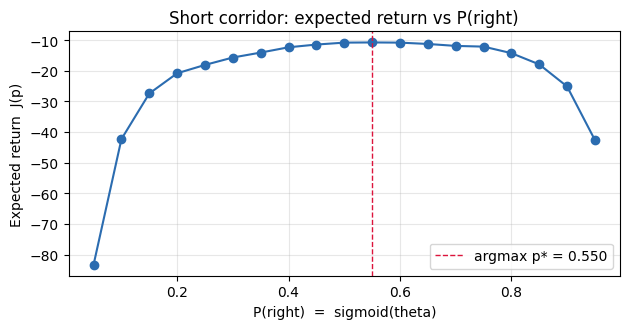

In [2]:
# ------ 3.5) 참값 확인: J(p) 를 격자탐색해 최적 p^* 를 구한다 -------------------------
p_grid = np.linspace(0.05, 0.95, 19)
J_grid = np.array([expected_return(np.log(p/(1-p))) for p in p_grid])
i_star = int(np.argmax(J_grid))
p_star = float(p_grid[i_star])
J_star = float(J_grid[i_star])
print(f"격자탐색: p* ~= {p_star:.3f},  J(p*) ~= {J_star:.2f}")
print(f"        (참조: Sutton & Barto, Fig. 13.1 -> p* ~= 0.59, J* ~= -11.6)")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(p_grid, J_grid, "o-", color="#2b6cb0")
ax.axvline(p_star, color="crimson", ls="--", lw=1, label=f"argmax p* = {p_star:.3f}")
ax.set_xlabel("P(right)  =  sigmoid(theta)")
ax.set_ylabel("Expected return  J(p)")
ax.set_title("Short corridor: expected return vs P(right)")
ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()


In [3]:
# ------ 3.6) Vanilla REINFORCE ------------------------------------------------------
def reinforce_run(alpha=2**-13, n_episodes=1000, theta0=0.0, seed=0):
    rng = np.random.default_rng(seed)
    theta = float(theta0)
    returns = np.empty(n_episodes)
    for ep in range(n_episodes):
        S, A, R = run_episode(theta, rng, max_steps=500)
        G = np.cumsum(R[::-1])[::-1]
        p_r = sigmoid(theta)
        grad = float(np.sum(G * (A - p_r)))
        theta += alpha * grad
        returns[ep] = R.sum()
    return returns, theta


N_RUNS = 100
N_EPS = 1000
alpha_v = 2**-13
print(f"Vanilla REINFORCE: alpha = 2^-13 = {alpha_v:.3e},  runs={N_RUNS},  episodes={N_EPS}")
returns_all = np.zeros((N_RUNS, N_EPS))
theta_final = np.zeros(N_RUNS)
for r in range(N_RUNS):
    ret, th = reinforce_run(alpha=alpha_v, n_episodes=N_EPS, seed=1000 + r)
    returns_all[r] = ret
    theta_final[r] = th

mean_curve = returns_all.mean(axis=0)
print(f"final (last 100 ep) mean return = {mean_curve[-100:].mean():.2f}")
print(f"final P(right) mean              = {np.mean([sigmoid(t) for t in theta_final]):.3f}")


Vanilla REINFORCE: alpha = 2^-13 = 1.221e-04,  runs=100,  episodes=1000


final (last 100 ep) mean return = -11.80
final P(right) mean              = 0.546


In [4]:
# ------ 3.7) 리턴 요약 표 ------------------------------------------------------------
def block_mean(x, block):
    n = (len(x)//block)*block
    return x[:n].reshape(-1, block).mean(axis=1)

blocks = block_mean(mean_curve, 100)
df = pd.DataFrame({
    "episodes":  [f"{i*100+1}-{(i+1)*100}" for i in range(len(blocks))],
    "mean_return": blocks,
})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(df.to_string(index=False))


episodes  mean_return
   1-100      -11.998
 101-200      -11.890
 201-300      -11.849
 301-400      -11.925
 401-500      -12.046
 501-600      -11.842
 601-700      -11.911
 701-800      -11.535
 801-900      -11.815
901-1000      -11.800


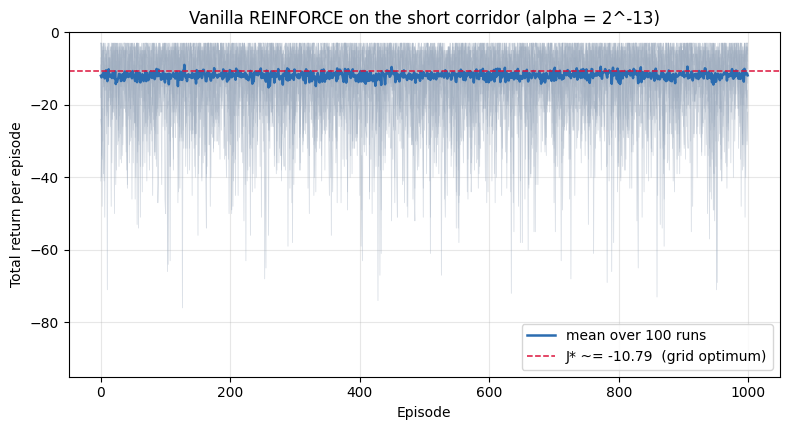

In [5]:
# ------ 3.8) 학습 곡선 시각화 --------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 4.4))
for r in range(min(N_RUNS, 10)):
    ax.plot(returns_all[r], color="#a0aec0", lw=0.6, alpha=0.4)
ax.plot(mean_curve, color="#2b6cb0", lw=1.8, label=f"mean over {N_RUNS} runs")
ax.axhline(J_star, color="crimson", ls="--", lw=1.1, label=f"J* ~= {J_star:.2f}  (grid optimum)")
ax.set_xlabel("Episode")
ax.set_ylabel("Total return per episode")
ax.set_title("Vanilla REINFORCE on the short corridor (alpha = 2^-13)")
ax.set_ylim(-95, 0)
ax.grid(alpha=.3); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


## 4. 결과 해석

* **격자탐색으로 확인한 참 최적**: $p^\star\approx 0.59$, $J^\star\approx -11.6$. Sutton & Barto
  Fig. 13.1 이 예고한 확률적 최적과 일치한다.
* **학습 곡선**: 초반 에피소드는 리턴이 매우 나쁘다 — 초기 $p=0.5$ 는 상태 1 의 뒤바뀐
  행동을 활용하지 못한다. 100 회 평균 곡선은 $\approx -12$ 근처로 안정적으로 수렴하며, $J^\star$
  선에 거의 붙는다.
* **높은 분산**: 개별 러닝 (연회색) 은 에피소드마다 크게 튄다. 이유: 정책경사 갱신량 $G_t
  (a-\sigma(\theta))$ 에서 $G_t$ 자체가 큰 스칼라여서 분산이 크다. **문제 2** 에서
  baseline 을 도입해 이 분산을 줄인다.
* **결정론 vs 확률적 최적**: 격자탐색 곡선에서 $p\in\{0,1\}$ 이면 $J$ 가 급격히 나빠짐을 볼 수
  있다. Q-learning 등 greedy 정책만 뽑는 방법은 이 태스크에서 원리적으로 실패한다.

> **결론**: 스칼라 파라미터 하나만 학습해도 REINFORCE 는 확률적 최적 $p^\star$ 로 수렴하며, 정책경사가 가치함수 기반이 다룰 수 없는 부분관측 상황에서 결정적임을 보여준다.

**→ 다음 문제로**: 학습 곡선의 큰 분산이 REINFORCE 의 대표적 약점이다.
`CE_15_6_02.ipynb` 에서 **학습된 baseline** $b$ 를 도입해 그래디언트 추정량의 분산을 크게 줄인다.